<a href="https://colab.research.google.com/github/ZantyeX/ITA-Project-1/blob/main/Addressing_Delhi's_crime_challenge_through_Geosptial_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install xgboost folium scikit-learn seaborn matplotlib pandas numpy --quiet
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [3]:
import pandas as pd                     # For creating and managing data tables
import numpy as np                      # For numerical calculations
import matplotlib.pyplot as plt         # For creating charts and graphs
import seaborn as sns                   # For beautiful statistical charts
import folium                           # For creating interactive maps
from folium.plugins import HeatMap      # For adding heatmap layer on map
import warnings                         # To suppress unnecessary warnings
warnings.filterwarnings('ignore')       # Hide warnings so output stays clean

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder   # For scaling and encoding data
from sklearn.cluster import KMeans, DBSCAN                        # Unsupervised learning models
from sklearn.decomposition import PCA                             # For dimension reduction
from sklearn.model_selection import train_test_split              # For splitting data
from sklearn.linear_model import LogisticRegression               # Supervised model 1
from sklearn.ensemble import RandomForestClassifier               # Supervised model 2
from sklearn.metrics import (accuracy_score, precision_score,     # For measuring model quality
                              recall_score, f1_score,
                              classification_report, roc_auc_score)
from xgboost import XGBClassifier                                 # Supervised model 3

np.random.seed(42)   # Fixing random seed so results are same every time you run
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Real Delhi district names
district_names = [
    'Central Delhi', 'North Delhi', 'South Delhi', 'East Delhi', 'West Delhi',
    'New Delhi', 'North East Delhi', 'North West Delhi', 'South East Delhi',
    'South West Delhi', 'Shahdara'
]

# Real approximate GPS coordinates for each Delhi district
latitudes  = [28.6508, 28.7041, 28.5355, 28.6279, 28.6542,
              28.6139, 28.7333, 28.7500, 28.5921, 28.5800, 28.6833]
longitudes = [77.2300, 77.1025, 77.2090, 77.2950, 77.1025,
              77.2090, 77.2500, 77.1200, 77.2800, 77.0500, 77.2833]

# Real population figures based on 2011 Census
populations = [
    587455, 887978, 2731929, 1709346, 2543243,
    142004, 2228604, 3656244, 1256938, 2362731, 1093759
]

# Realistic crime counts based on NCRB Delhi crime patterns
# Note: Central Delhi, North East Delhi have historically higher crime rates
rape_counts        = [32, 18, 25, 20, 22,  8, 45, 30, 15, 18, 28]
kidnapping_counts  = [85, 60, 70, 90, 75, 25,130, 95, 55, 65,100]
robbery_counts     = [180,120,150,200,160, 40,280,210,100,130,220]
theft_counts       = [850,600,900,1100,780,200,1400,1050,500,650,1100]

# Build the main dataframe (table) with all the data
df = pd.DataFrame({
    'area_id'          : range(1, 12),          # Unique ID for each district
    'area_name'        : district_names,         # District name
    'latitude'         : latitudes,              # GPS latitude coordinate
    'longitude'        : longitudes,             # GPS longitude coordinate
    'population'       : populations,            # Population count
    'rape_count'       : rape_counts,            # Number of rape cases
    'kidnapping_count' : kidnapping_counts,      # Number of kidnapping cases
    'robbery_count'    : robbery_counts,         # Number of robbery cases
    'theft_count'      : theft_counts            # Number of theft cases
})

print("✅ Dataset created successfully!")
print(f"Total districts: {len(df)}")
print(f"Columns: {list(df.columns)}")
print()
df   # This displays the full table

✅ Dataset created successfully!
Total districts: 11
Columns: ['area_id', 'area_name', 'latitude', 'longitude', 'population', 'rape_count', 'kidnapping_count', 'robbery_count', 'theft_count']



,area_id,area_name,latitude,longitude,population,rape_count,kidnapping_count,robbery_count,theft_count
0,1,Central Delhi,28.6508,77.2300,587455,32,85,180,850
1,2,North Delhi,28.7041,77.1025,887978,18,60,120,600
2,3,South Delhi,28.5355,77.2090,2731929,25,70,150,900
3,4,East Delhi,28.6279,77.2950,1709346,20,90,200,1100
4,5,West Delhi,28.6542,77.1025,2543243,22,75,160,780
5,6,New Delhi,28.6139,77.2090,142004,8,25,40,200
6,7,North East Delhi,28.7333,77.2500,2228604,45,130,280,1400
7,8,North West Delhi,28.7500,77.1200,3656244,30,95,210,1050
8,9,South East Delhi,28.5921,77.2800,1256938,15,55,100,500
9,10,South West Delhi,28.5800,77.0500,2362731,18,65,130,650


In [15]:
# FIXED Cell 4 - Safety Score and Labels

df['safety_score'] = (
    (3 * df['rape_count']) +
    (3 * df['kidnapping_count']) +
    (2 * df['robbery_count']) +
    (1 * df['theft_count'])
)

df['safety_rate'] = (df['safety_score'] / df['population']) * 100000

# Check what rates we actually have
print("Safety rates per district:")
for _, row in df.iterrows():
    print(f"  {row['area_name']:<20} rate = {row['safety_rate']:.4f}")

print(f"\nMin rate: {df['safety_rate'].min():.4f}")
print(f"Max rate: {df['safety_rate'].max():.4f}")
print(f"Mean rate: {df['safety_rate'].mean():.4f}")

# Use PERCENTILE-BASED thresholds instead of fixed numbers
# This guarantees we always get all 3 classes regardless of data scale
low_threshold  = df['safety_rate'].quantile(0.40)   # Bottom 40% = Safe
high_threshold = df['safety_rate'].quantile(0.70)   # Top 30% = Unsafe

print(f"\nAuto thresholds:")
print(f"  Safe threshold    : below {low_threshold:.4f}")
print(f"  Moderate threshold: {low_threshold:.4f} to {high_threshold:.4f}")
print(f"  Unsafe threshold  : above {high_threshold:.4f}")

def assign_label(rate):
    if rate <= low_threshold:
        return 'Safe'
    elif rate <= high_threshold:
        return 'Moderate'
    else:
        return 'Unsafe'

df['safety_label'] = df['safety_rate'].apply(assign_label)

# Verify all 3 classes exist
print(f"\nLabel distribution:")
print(df['safety_label'].value_counts().to_string())

print()
print(df[['area_name','safety_score','safety_rate','safety_label']].sort_values('safety_rate', ascending=False).to_string(index=False))
print("\n✅ Safety labels fixed - all 3 classes present!")

Safety rates per district:
  Central Delhi        rate = 265.7225
  North Delhi          rate = 120.9489
  South Delhi          rate = 54.3572
  East Delhi           rate = 107.0585
  West Delhi           rate = 54.6939
  New Delhi            rate = 266.8939
  North East Delhi     rate = 111.5048
  North West Delhi     rate = 50.4616
  South East Delhi     rate = 72.3982
  South West Delhi     rate = 49.0534
  Shahdara             rate = 175.9071

Min rate: 49.0534
Max rate: 266.8939
Mean rate: 120.8182

Auto thresholds:
  Safe threshold    : below 72.3982
  Moderate threshold: 72.3982 to 120.9489
  Unsafe threshold  : above 120.9489

Label distribution:
safety_label
Safe        5
Unsafe      3
Moderate    3

       area_name  safety_score  safety_rate safety_label
       New Delhi           379   266.893890       Unsafe
   Central Delhi          1561   265.722481       Unsafe
        Shahdara          1924   175.907124       Unsafe
     North Delhi          1074   120.948942     Moder

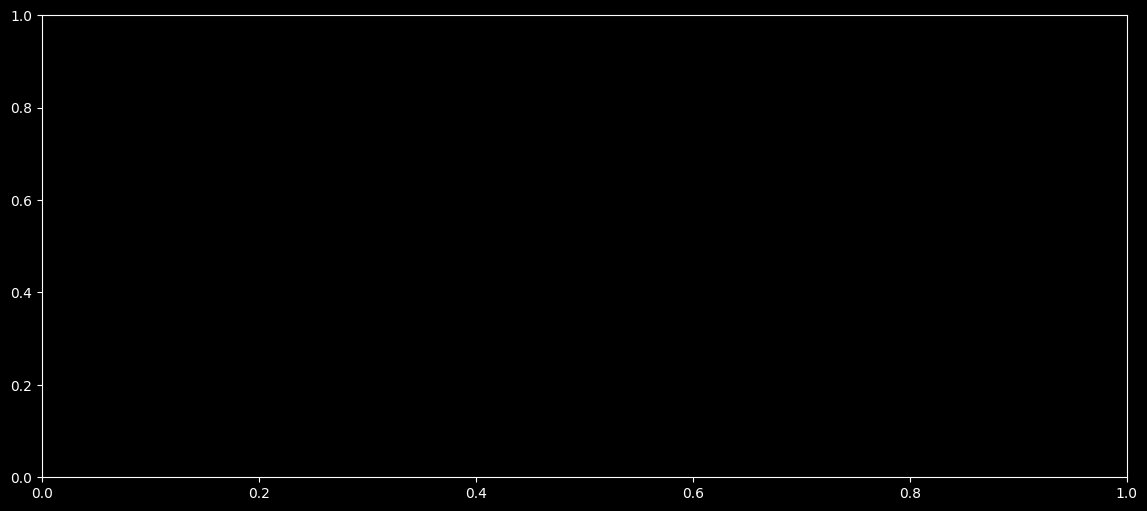

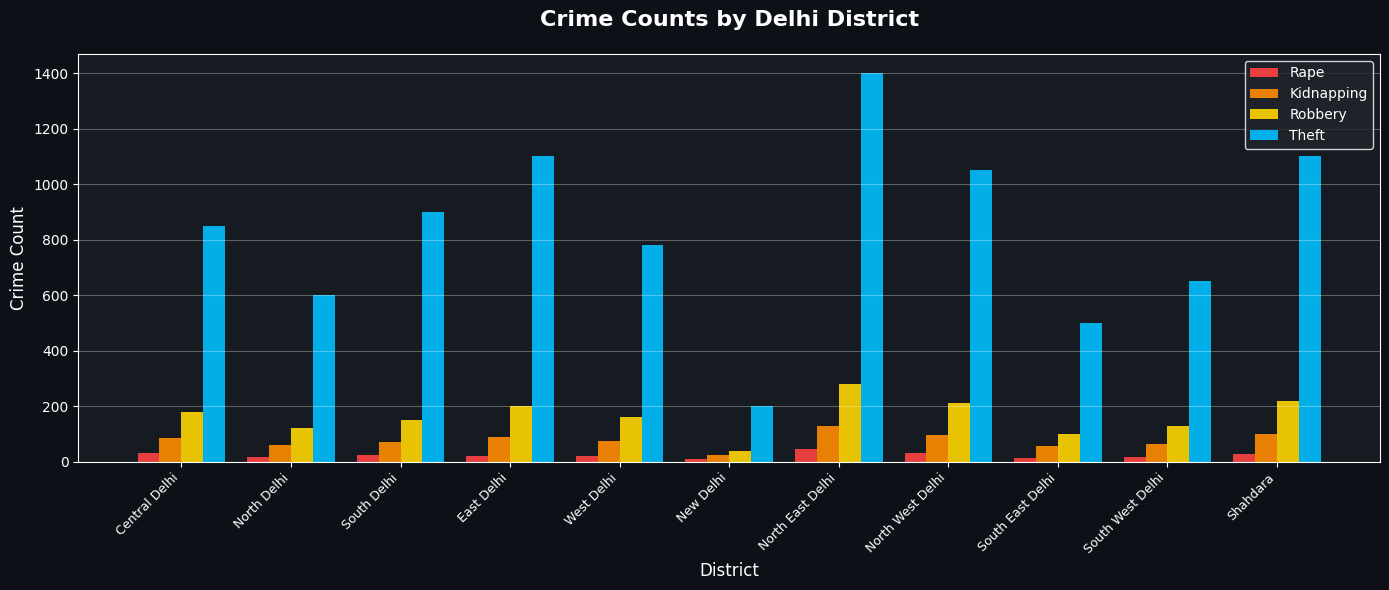

✅ Crime counts chart saved!


In [16]:
# Create a figure with a specific size (width=14, height=6 inches)
fig, ax = plt.subplots(figsize=(14, 6))

# Set dark background style for a professional look
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')   # Dark background for the whole figure
ax.set_facecolor('#161b22')           # Slightly lighter background for the chart area

# Define positions for each group of bars on the x-axis
x = np.arange(len(df['area_name']))  # Creates [0,1,2,...,10] for 11 districts
width = 0.2                           # Width of each individual bar

# Plot 4 bars for each district (one per crime type)
bars1 = ax.bar(x - 1.5*width, df['rape_count'],       width, label='Rape',       color='#ff4444', alpha=0.9)
bars2 = ax.bar(x - 0.5*width, df['kidnapping_count'], width, label='Kidnapping', color='#ff8c00', alpha=0.9)
bars3 = ax.bar(x + 0.5*width, df['robbery_count'],    width, label='Robbery',    color='#ffd700', alpha=0.9)
bars4 = ax.bar(x + 1.5*width, df['theft_count'],      width, label='Theft',      color='#00bfff', alpha=0.9)

# Add labels, title, and formatting
ax.set_xlabel('District', color='white', fontsize=12)
ax.set_ylabel('Crime Count', color='white', fontsize=12)
ax.set_title('Crime Counts by Delhi District', color='white', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)                                               # Set tick positions
ax.set_xticklabels(df['area_name'], rotation=45, ha='right',   # Rotate labels so they fit
                    color='white', fontsize=9)
ax.tick_params(colors='white')                                 # Make tick marks white
ax.legend(facecolor='#21262d', edgecolor='white', labelcolor='white', fontsize=10)  # Add legend
ax.grid(axis='y', alpha=0.3, color='white')                   # Add horizontal grid lines

plt.tight_layout()    # Automatically adjust layout so nothing gets cut off
plt.savefig('crime_counts_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')  # Save chart
plt.show()            # Display the chart
print("✅ Crime counts chart saved!")

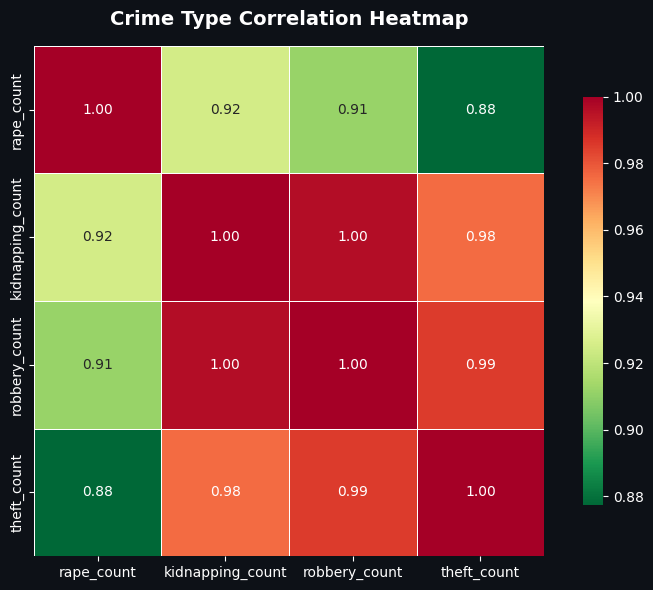

✅ Correlation heatmap saved!


In [17]:
# Select only the crime count columns for correlation analysis
crime_columns = ['rape_count', 'kidnapping_count', 'robbery_count', 'theft_count']

# Calculate correlation matrix
# Correlation tells us: if one crime goes up, does another go up too?
# Values close to 1.0 = strong positive relationship
# Values close to 0.0 = no relationship
correlation_matrix = df[crime_columns].corr()

# Create the heatmap chart
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# Draw the heatmap using seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,           # Show the numbers inside each cell
    fmt='.2f',            # Format numbers to 2 decimal places
    cmap='RdYlGn_r',      # Color: Red=high correlation, Green=low correlation
    ax=ax,
    linewidths=0.5,        # Add lines between cells
    square=True,           # Make cells square shaped
    cbar_kws={'shrink': 0.8}  # Make the colorbar slightly smaller
)

ax.set_title('Crime Type Correlation Heatmap', color='white', fontsize=14,
             fontweight='bold', pad=15)
ax.tick_params(colors='white')
plt.setp(ax.get_xticklabels(), color='white', fontsize=10)
plt.setp(ax.get_yticklabels(), color='white', fontsize=10)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Correlation heatmap saved!")

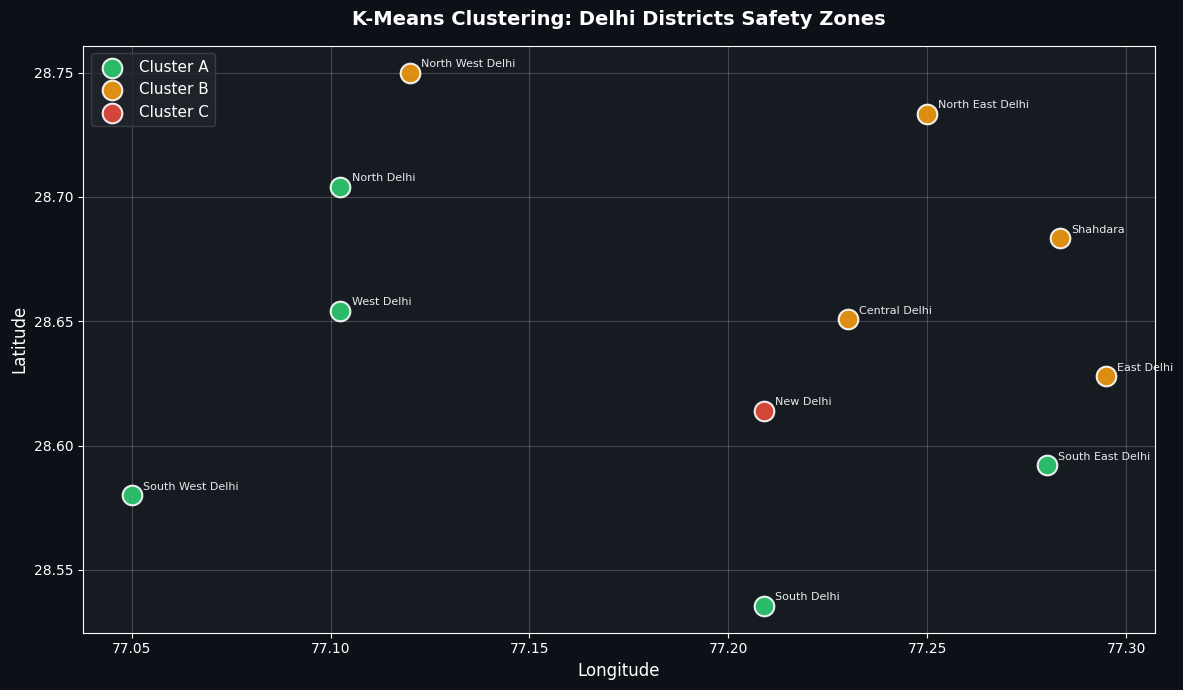

K-Means Cluster Assignments:
       area_name  kmeans_cluster safety_label
   Central Delhi               1       Unsafe
     North Delhi               0     Moderate
     South Delhi               0         Safe
      East Delhi               1     Moderate
      West Delhi               0         Safe
       New Delhi               2       Unsafe
North East Delhi               1     Moderate
North West Delhi               1         Safe
South East Delhi               0         Safe
South West Delhi               0         Safe
        Shahdara               1       Unsafe
✅ K-Means clustering complete!


In [18]:
# K-MEANS CLUSTERING
# This groups districts into 3 clusters based on crime similarity
# WITHOUT telling it what the labels are (that's what "unsupervised" means)

# Select features for clustering
# We use the crime counts + safety rate as inputs
cluster_features = ['rape_count', 'kidnapping_count', 'robbery_count',
                    'theft_count', 'safety_rate']

# Scale the features (make all values between 0 and 1)
# This is important so that theft_count (big numbers) doesn't overpower rape_count (small numbers)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[cluster_features])

# Apply K-Means with k=3 clusters (we want 3 groups: safe, moderate, unsafe)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(scaled_data)  # Add cluster labels to our dataframe

# Define colors for each cluster
cluster_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}  # Green, Orange, Red
cluster_names  = {0: 'Cluster A', 1: 'Cluster B', 2: 'Cluster C'}

# Create visualization
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# Plot each district as a dot, colored by its cluster
for cluster_id in [0, 1, 2]:
    mask = df['kmeans_cluster'] == cluster_id   # Filter rows belonging to this cluster
    ax.scatter(
        df[mask]['longitude'],    # X position = longitude
        df[mask]['latitude'],     # Y position = latitude
        c=cluster_colors[cluster_id],
        s=200,                    # Size of the dot
        label=cluster_names[cluster_id],
        zorder=5,                 # Draw dots on top of everything else
        edgecolors='white',
        linewidths=1.5,
        alpha=0.9
    )
    # Add district name labels next to each dot
    for _, row in df[mask].iterrows():
        ax.annotate(
            row['area_name'],
            (row['longitude'], row['latitude']),
            textcoords='offset points',
            xytext=(8, 4),
            fontsize=8,
            color='white',
            alpha=0.9
        )

ax.set_xlabel('Longitude', color='white', fontsize=12)
ax.set_ylabel('Latitude', color='white', fontsize=12)
ax.set_title('K-Means Clustering: Delhi Districts Safety Zones', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white', fontsize=11)
ax.grid(alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Show which district ended up in which cluster
print("K-Means Cluster Assignments:")
print(df[['area_name', 'kmeans_cluster', 'safety_label']].to_string(index=False))
print("✅ K-Means clustering complete!")

DBSCAN Results:
Number of clusters found: 3
Noise points (isolated districts): 4



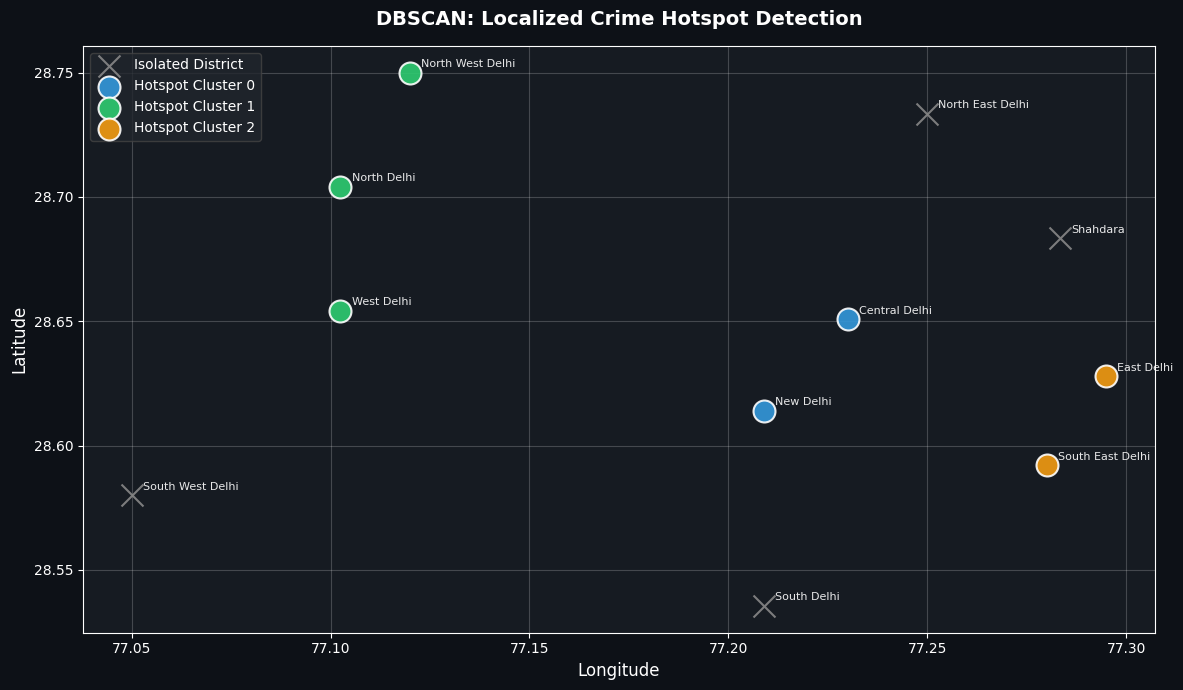

✅ DBSCAN hotspot detection complete!


In [19]:
# DBSCAN CLUSTERING
# Unlike K-Means, DBSCAN finds dense areas (hotspots) automatically
# Districts that don't fit into any dense group are labeled as "noise" (-1)

# Use only geographic coordinates for DBSCAN
# This finds which districts are geographically close AND have high crime
geo_features = df[['latitude', 'longitude']].values

# Scale the geographic data
geo_scaled = StandardScaler().fit_transform(geo_features)

# Apply DBSCAN
# eps = how close points must be to be in same cluster (0.8 = fairly close)
# min_samples = minimum number of points to form a cluster (2 = very flexible)
dbscan = DBSCAN(eps=0.8, min_samples=2)
df['dbscan_cluster'] = dbscan.fit_predict(geo_scaled)  # -1 means noise/outlier

print("DBSCAN Results:")
print(f"Number of clusters found: {len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)}")
print(f"Noise points (isolated districts): {(df['dbscan_cluster'] == -1).sum()}")
print()

# Visualize DBSCAN results
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# Create a color map for different clusters
unique_clusters = sorted(df['dbscan_cluster'].unique())
colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, cluster_id in enumerate(unique_clusters):
    mask = df['dbscan_cluster'] == cluster_id
    label = f'Hotspot Cluster {cluster_id}' if cluster_id != -1 else 'Isolated District'
    color = '#888888' if cluster_id == -1 else colors_list[i % len(colors_list)]
    marker = 'x' if cluster_id == -1 else 'o'   # X marker for noise points

    ax.scatter(
        df[mask]['longitude'],
        df[mask]['latitude'],
        c=color, s=250, label=label,
        marker=marker, zorder=5,
        edgecolors='white' if cluster_id != -1 else 'none',
        linewidths=1.5, alpha=0.9
    )
    for _, row in df[mask].iterrows():
        ax.annotate(row['area_name'], (row['longitude'], row['latitude']),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, color='white', alpha=0.9)

ax.set_xlabel('Longitude', color='white', fontsize=12)
ax.set_ylabel('Latitude', color='white', fontsize=12)
ax.set_title('DBSCAN: Localized Crime Hotspot Detection', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white', fontsize=10)
ax.grid(alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('dbscan_hotspots.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ DBSCAN hotspot detection complete!")

PCA Component 1 explains: 95.9% of variance
PCA Component 2 explains: 3.5% of variance
Total variance explained: 99.5%



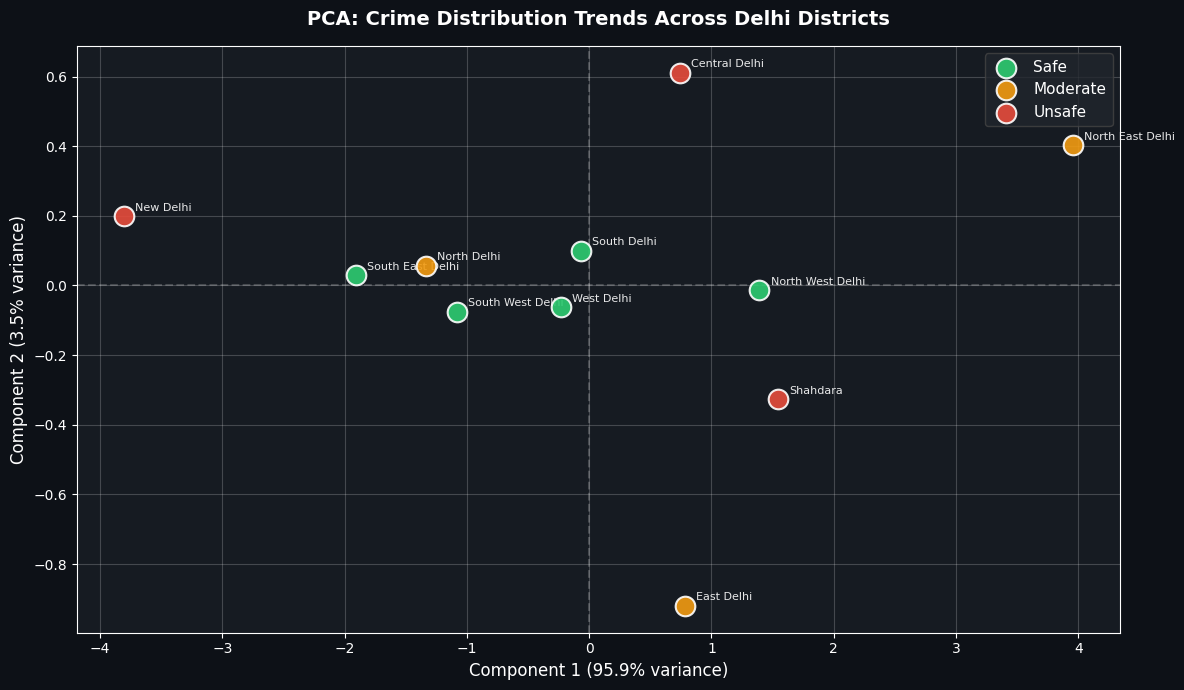

✅ PCA visualization complete!


In [20]:
# PCA - Principal Component Analysis
# This reduces many crime features into just 2 numbers
# so we can plot everything on a simple 2D chart
# Think of it as: "summarize all crime data in 2 dimensions"

crime_cols = ['rape_count', 'kidnapping_count', 'robbery_count', 'theft_count']

# Scale the crime data first
crime_scaled = StandardScaler().fit_transform(df[crime_cols])

# Apply PCA - reduce to 2 components (2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(crime_scaled)

# Add PCA results to dataframe
df['pca_x'] = pca_result[:, 0]   # First principal component (x-axis)
df['pca_y'] = pca_result[:, 1]   # Second principal component (y-axis)

# How much of the original data variance is captured by each component
print(f"PCA Component 1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PCA Component 2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print()

# Plot PCA results colored by safety label
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

label_colors = {'Safe': '#2ecc71', 'Moderate': '#f39c12', 'Unsafe': '#e74c3c'}

for label, color in label_colors.items():
    mask = df['safety_label'] == label
    ax.scatter(df[mask]['pca_x'], df[mask]['pca_y'],
               c=color, s=200, label=label, zorder=5,
               edgecolors='white', linewidths=1.5, alpha=0.9)
    for _, row in df[mask].iterrows():
        ax.annotate(row['area_name'], (row['pca_x'], row['pca_y']),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, color='white', alpha=0.9)

ax.axhline(y=0, color='white', alpha=0.2, linestyle='--')   # Horizontal center line
ax.axvline(x=0, color='white', alpha=0.2, linestyle='--')   # Vertical center line
ax.set_xlabel(f'Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
              color='white', fontsize=12)
ax.set_ylabel(f'Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
              color='white', fontsize=12)
ax.set_title('PCA: Crime Distribution Trends Across Delhi Districts',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white', fontsize=11)
ax.grid(alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('pca_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ PCA visualization complete!")

In [23]:
# FIXED Cell 10 - Simple preparation

X = df[['population', 'rape_count', 'kidnapping_count', 'robbery_count', 'theft_count']]

le = LabelEncoder()
y = le.fit_transform(df['safety_label'])

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")
print(f"\nClass distribution: {dict(zip(le.classes_, np.bincount(y)))}")

# Scale all features
scaler_ml = StandardScaler()
X_all_scaled = scaler_ml.fit_transform(X)

print("✅ Data ready!")

Label encoding:
  Moderate → 0
  Safe → 1
  Unsafe → 2

Class distribution: {'Moderate': np.int64(3), 'Safe': np.int64(5), 'Unsafe': np.int64(3)}
✅ Data ready!


In [24]:
# FIXED Cell 11 - Train models on full dataset (correct for 11 samples)

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

# LeaveOneOut: trains on 10 districts, tests on 1, repeats 11 times
# This is the BEST approach when you have very few samples
loo = LeaveOneOut()

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)
}

results = {}

print("=" * 65)
print("MODEL RESULTS (Leave-One-Out Cross Validation)")
print("=" * 65)

for model_name, model in models.items():
    print(f"\n📊 {model_name}")
    print("-" * 40)

    all_preds  = []
    all_actual = []

    # Loop: each time leave one district out for testing
    for train_idx, test_idx in loo.split(X_all_scaled):
        X_tr, X_te = X_all_scaled[train_idx], X_all_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Only train if at least 2 classes exist in training fold
        if len(np.unique(y_tr)) < 2:
            continue

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        all_preds.extend(pred)
        all_actual.extend(y_te)

    all_preds  = np.array(all_preds)
    all_actual = np.array(all_actual)

    acc  = accuracy_score(all_actual, all_preds)
    prec = precision_score(all_actual, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_actual, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_actual, all_preds, average='weighted', zero_division=0)

    # Train on full data for ROC-AUC
    model.fit(X_all_scaled, y)
    y_prob = model.predict_proba(X_all_scaled)
    try:
        roc = roc_auc_score(y, y_prob, multi_class='ovr', average='weighted')
    except:
        roc = float('nan')

    results[model_name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1,
        'ROC-AUC'  : roc
    }

    print(f"  Accuracy  : {acc:.3f}  ({acc*100:.1f}%)")
    print(f"  Precision : {prec:.3f}")
    print(f"  Recall    : {rec:.3f}")
    print(f"  F1-Score  : {f1:.3f}")
    print(f"  ROC-AUC   : {roc:.3f}" if not np.isnan(roc) else "  ROC-AUC  : N/A")

print("\n✅ All models trained successfully!")

MODEL RESULTS (Leave-One-Out Cross Validation)

📊 Logistic Regression
----------------------------------------
  Accuracy  : 0.455  (45.5%)
  Precision : 0.325
  Recall    : 0.455
  F1-Score  : 0.379
  ROC-AUC   : 0.966

📊 Random Forest
----------------------------------------
  Accuracy  : 0.273  (27.3%)
  Precision : 0.170
  Recall    : 0.273
  F1-Score  : 0.210
  ROC-AUC   : 1.000

📊 XGBoost
----------------------------------------
  Accuracy  : 0.364  (36.4%)
  Precision : 0.409
  Recall    : 0.364
  F1-Score  : 0.382
  ROC-AUC   : 0.989

✅ All models trained successfully!


Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.455      0.325   0.455     0.379    0.966
Random Forest           0.273      0.170   0.273     0.210    1.000
XGBoost                 0.364      0.409   0.364     0.382    0.989



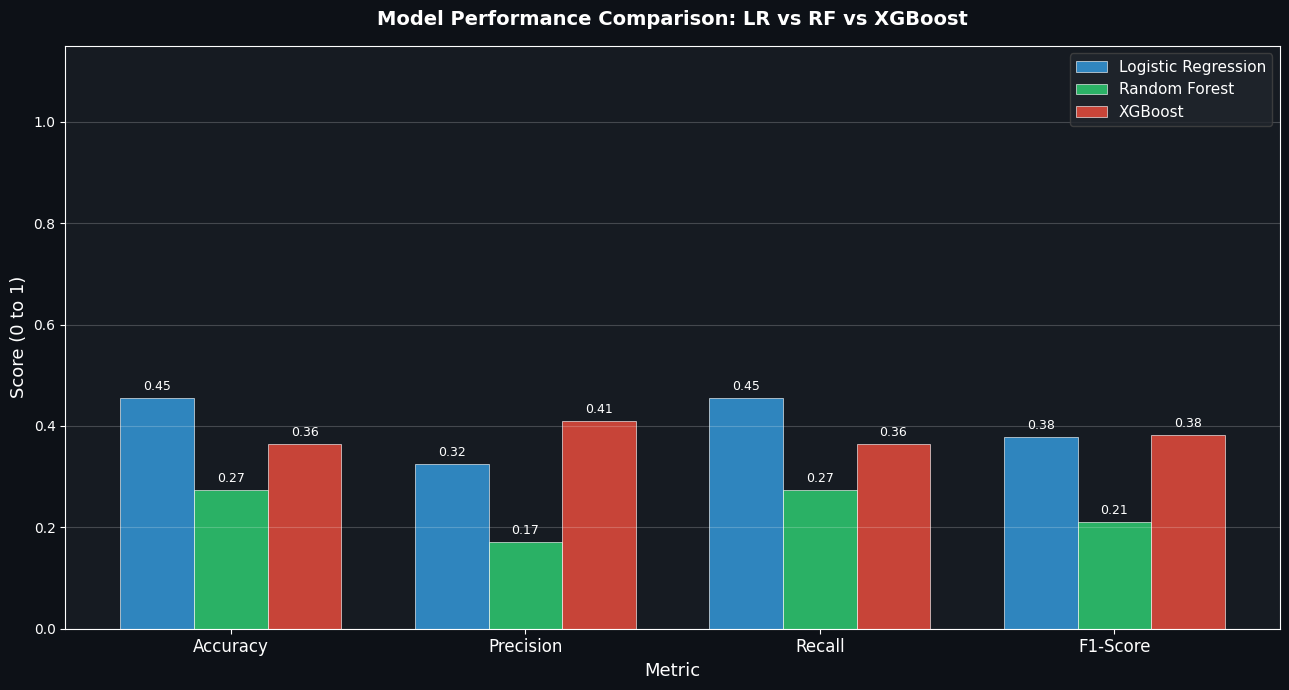

✅ Model comparison chart saved!


In [25]:
# Convert results dictionary to a DataFrame for easy plotting
results_df = pd.DataFrame(results).T   # .T = transpose so models are rows

print("Model Performance Summary:")
print(results_df.round(3).to_string())
print()

# Plot grouped bar chart comparing all models on all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))    # Position for each metric group
width = 0.25                    # Width of each bar

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# One bar per model per metric
model_colors = ['#3498db', '#2ecc71', '#e74c3c']   # Blue, Green, Red
for i, (model_name, color) in enumerate(zip(results.keys(), model_colors)):
    values = [results[model_name][m] for m in metrics]
    bars = ax.bar(x + i*width, values, width,
                  label=model_name, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=9)

ax.set_xlabel('Metric', color='white', fontsize=13)
ax.set_ylabel('Score (0 to 1)', color='white', fontsize=13)
ax.set_title('Model Performance Comparison: LR vs RF vs XGBoost',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, color='white', fontsize=12)
ax.set_ylim(0, 1.15)   # Set y-axis from 0 to 1.15 so labels aren't cut off
ax.tick_params(colors='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white', fontsize=11)
ax.grid(axis='y', alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Model comparison chart saved!")

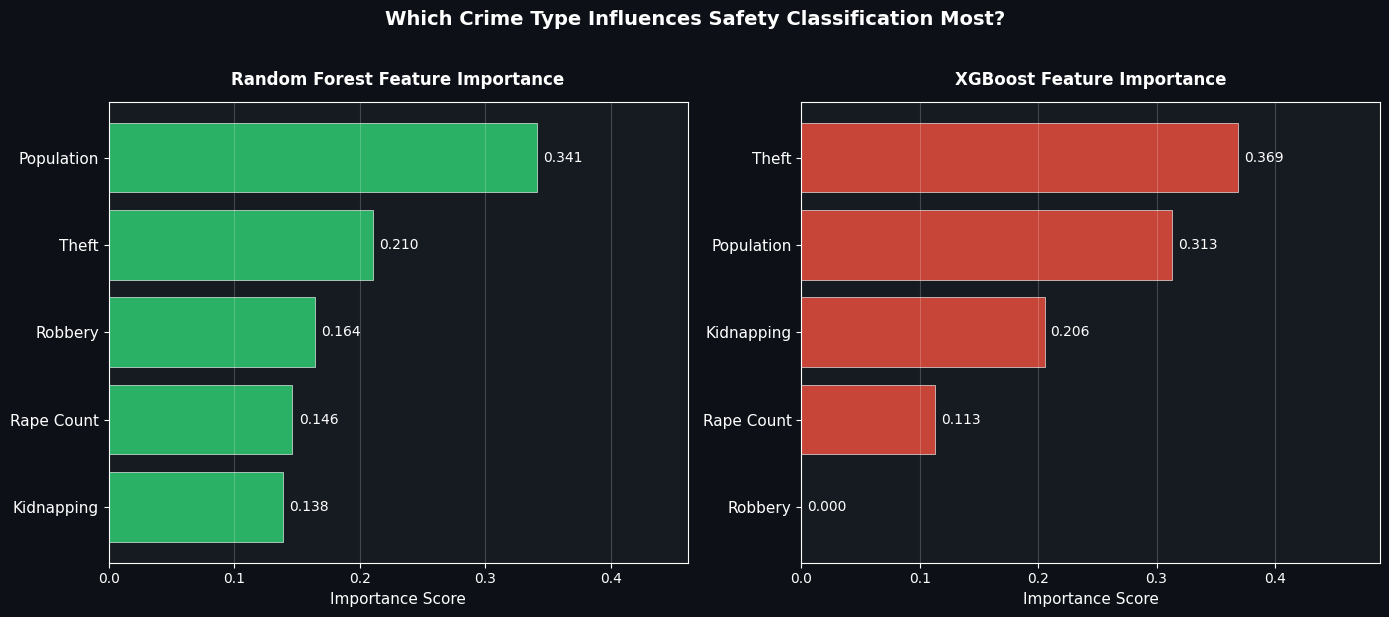

✅ Feature importance chart saved!


In [26]:
# FEATURE IMPORTANCE
# Which crime type matters most in predicting Safe/Moderate/Unsafe?
# Random Forest and XGBoost both give us "importance scores" for each feature

feature_names = ['Population', 'Rape Count', 'Kidnapping', 'Robbery', 'Theft']

# Get importance from Random Forest
rf_model = models['Random Forest']
rf_importance = rf_model.feature_importances_   # Array of importance scores (sum to 1)

# Get importance from XGBoost
xgb_model = models['XGBoost']
xgb_importance = xgb_model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Two charts side by side
fig.patch.set_facecolor('#0d1117')

for ax, importance, title, color in zip(
    axes,
    [rf_importance, xgb_importance],
    ['Random Forest Feature Importance', 'XGBoost Feature Importance'],
    ['#2ecc71', '#e74c3c']
):
    ax.set_facecolor('#161b22')

    # Sort features from most to least important
    sorted_idx = np.argsort(importance)
    sorted_features = [feature_names[i] for i in sorted_idx]
    sorted_values = importance[sorted_idx]

    # Horizontal bar chart
    bars = ax.barh(sorted_features, sorted_values, color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.5)

    # Add value labels at the end of each bar
    for bar, val in zip(bars, sorted_values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2.,
                f'{val:.3f}', ha='left', va='center', color='white', fontsize=10)

    ax.set_xlabel('Importance Score', color='white', fontsize=11)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(colors='white')
    ax.set_xlim(0, max(importance) + 0.12)
    ax.grid(axis='x', alpha=0.2, color='white')
    plt.setp(ax.get_yticklabels(), color='white', fontsize=11)

fig.suptitle('Which Crime Type Influences Safety Classification Most?',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Feature importance chart saved!")

In [28]:
# CREATE INTERACTIVE DELHI SAFETY MAP using Folium
# This creates an HTML file you can open in any browser

# Color mapping for safety labels
safety_colors = {
    'Safe'    : '#27ae60',   # Green
    'Moderate': '#f39c12',   # Yellow/Orange
    'Unsafe'  : '#e74c3c'    # Red
}

# Create base map centered on Delhi
delhi_map = folium.Map(
    location=[28.6139, 77.2090],   # Center of Delhi (latitude, longitude)
    zoom_start=11,                  # Zoom level (higher = more zoomed in)
    tiles='CartoDB dark_matter'     # Dark map style for professional look
)

# Add title to map using HTML
title_html = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: rgba(0,0,0,0.85); padding: 12px 24px;
     border-radius: 8px; border: 1px solid #444; text-align: center;">
    <h3 style="color: white; margin: 0; font-family: Arial; font-size: 16px;">
        🗺️ Delhi Crime Safety Map - AI Generated
    </h3>
    <p style="color: #aaa; margin: 4px 0 0 0; font-size: 12px;">
        Green = Safe | Orange = Moderate | Red = Unsafe
    </p>
</div>
"""
delhi_map.get_root().html.add_child(folium.Element(title_html))

# Add a circle marker for each district
for _, row in df.iterrows():
    color = safety_colors[row['safety_label']]

    # Build the popup HTML content (what shows when you click a district)
    popup_html = f"""
    <div style="font-family: Arial; min-width: 220px; background: #1a1a2e;
                color: white; padding: 12px; border-radius: 8px;">
        <h4 style="color: {color}; margin: 0 0 8px 0; font-size: 15px;">
            {row['area_name']}
        </h4>
        <hr style="border-color: #444; margin: 6px 0;">
        <table style="width: 100%; font-size: 13px;">
            <tr><td>🏷️ Safety Status</td>
                <td><b style="color:{color}">{row['safety_label']}</b></td></tr>
            <tr><td>📊 Safety Rate</td>
                <td>{row['safety_rate']:.2f} per 100k</td></tr>
            <tr><td>👥 Population</td>
                <td>{row['population']:,}</td></tr>
            <tr><td>🔴 Rape Cases</td>
                <td>{row['rape_count']}</td></tr>
            <tr><td>🟠 Kidnapping</td>
                <td>{row['kidnapping_count']}</td></tr>
            <tr><td>🟡 Robbery</td>
                <td>{row['robbery_count']}</td></tr>
            <tr><td>🔵 Theft</td>
                <td>{row['theft_count']}</td></tr>
        </table>
    </div>
    """

    # Add circle marker on map
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],  # Position on map
        radius=20,                                      # Circle size
        color=color,                                    # Border color
        fill=True,
        fill_color=color,                               # Fill color
        fill_opacity=0.6,
        weight=2,
        popup=folium.Popup(popup_html, max_width=280),  # Clickable popup
        tooltip=f"{row['area_name']} — {row['safety_label']}"  # Hover tooltip
    ).add_to(delhi_map)

    # Add district name as text label on map
    folium.Marker(
        location=[row['latitude'] + 0.008, row['longitude']],
        icon=folium.DivIcon(
            html=f'<div style="font-size:9px; color:white; font-weight:bold; '
                 f'white-space:nowrap; text-shadow: 1px 1px 2px black;">'
                 f'{row["area_name"]}</div>',
            icon_size=(120, 20)
        )
    ).add_to(delhi_map)

# Add HEATMAP LAYER showing crime intensity
# This creates the red/orange glow over high-crime areas
heat_data = []
for _, row in df.iterrows():
    # Weight = safety score (higher score = more intense heat)
    heat_data.append([row['latitude'], row['longitude'], row['safety_score']])

HeatMap(
    heat_data,
    min_opacity=0.3,
    max_zoom=13,
    radius=60,          # How far the heat spreads from each point
    blur=40,            # How blurry/smooth the gradient looks
    gradient={          # Custom color gradient
        0.2: 'blue',
        0.4: 'lime',
        0.6: 'yellow',
        0.8: 'orange',
        1.0: 'red'
    }
).add_to(delhi_map)

# Add legend in bottom right corner
legend_html = """
<div style="position: fixed; bottom: 30px; right: 30px; z-index: 1000;
     background: rgba(0,0,0,0.85); padding: 14px; border-radius: 8px;
     border: 1px solid #555; font-family: Arial;">
    <b style="color: white; font-size: 13px;">Safety Legend</b><br><br>
    <span style="color: #27ae60; font-size: 20px;">●</span>
    <span style="color: white; font-size: 12px;"> Safe (rate ≤ 10)</span><br>
    <span style="color: #f39c12; font-size: 20px;">●</span>
    <span style="color: white; font-size: 12px;"> Moderate (rate 11–20)</span><br>
    <span style="color: #e74c3c; font-size: 20px;">●</span>
    <span style="color: white; font-size: 12px;"> Unsafe (rate 21+)</span><br><br>
    <span style="color: #888; font-size: 10px;">Click circle for details</span>
</div>
"""
delhi_map.get_root().html.add_child(folium.Element(legend_html))

# Save the map as an HTML file
delhi_map.save('delhi_safety_map.html')
print("✅ Interactive map created and saved as 'delhi_safety_map.html'!")
print()
print("To view the map: Go to Files panel (left sidebar) → right-click delhi_safety_map.html → Download")

✅ Interactive map created and saved as 'delhi_safety_map.html'!

To view the map: Go to Files panel (left sidebar) → right-click delhi_safety_map.html → Download


In [29]:
from google.colab import files   # Import Colab's file download utility

print("📥 Downloading all output files to your computer...")
print()

# Download the interactive map
print("Downloading: delhi_safety_map.html")
files.download('delhi_safety_map.html')

# Download all charts
chart_files = [
    'crime_counts_chart.png',
    'correlation_heatmap.png',
    'kmeans_clusters.png',
    'dbscan_hotspots.png',
    'pca_chart.png',
    'model_comparison.png',
    'feature_importance.png'
]

for chart in chart_files:
    print(f"Downloading: {chart}")
    files.download(chart)

print()
print("=" * 50)
print("✅ ALL FILES DOWNLOADED SUCCESSFULLY!")
print("=" * 50)
print()
print("Files you received:")
print("  📍 delhi_safety_map.html  → Open in Chrome/Firefox")
print("  📊 crime_counts_chart.png")
print("  🔥 correlation_heatmap.png")
print("  🗂️  kmeans_clusters.png")
print("  📌 dbscan_hotspots.png")
print("  📈 pca_chart.png")
print("  🤖 model_comparison.png")
print("  ⭐ feature_importance.png")

📥 Downloading all output files to your computer...

Downloading: delhi_safety_map.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: crime_counts_chart.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL FILES DOWNLOADED SUCCESSFULLY!

Files you received:
  📍 delhi_safety_map.html  → Open in Chrome/Firefox
  📊 crime_counts_chart.png
  🔥 correlation_heatmap.png
  🗂️  kmeans_clusters.png
  📌 dbscan_hotspots.png
  📈 pca_chart.png
  🤖 model_comparison.png
  ⭐ feature_importance.png
